# Ejercicio 1

In [1]:
import pandas as pd
import numpy as np

ds_path = "../Datos/hawks.csv"

try:
    df = pd.read_csv(ds_path, encoding="cp1252", delimiter=";")
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Año,Especie,Ala,Peso,Cola,Hallux
0,1994,RT,2770,9400,218,304
1,1997,RT,3730,9140,221,304
2,2000,RT,3790,10000,217,322
3,2000,RT,3920,11850,229,330
4,2002,RT,3650,11250,213,293


In [2]:
# Correlación entre Ala y Cola
corr = df["Ala"].corr(df["Cola"])
print("Correlación entre Ala y Cola:", corr)

Correlación entre Ala y Cola: 0.8998883674343948


In [3]:
# Estadisticas sin normalizar
q1 = df["Hallux"].quantile(0.25)
q3 = df["Hallux"].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr
print("Estadisticas sin normalizar\n")
display(df["Hallux"].describe())
print("RIC:", iqr)
print("Bigote inferior:", lower_whisker)
print("Bigote superior:", upper_whisker)

# Estadisticas normalizadas
df["HalluxNorm"] = (df["Hallux"] - df["Hallux"].mean()) / df["Hallux"].std()
q1 = df["HalluxNorm"].quantile(0.25)
q3 = df["HalluxNorm"].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr
print("\nEstadisticas normalizadas\n")
display(df["HalluxNorm"].describe())
print("RIC:", iqr)
print("Bigote inferior:", lower_whisker)
print("Bigote superior:", upper_whisker)

Estadisticas sin normalizar



count    893.0000
mean     291.7716
std      321.3240
min       95.0000
25%      152.0000
50%      295.0000
75%      315.0000
max     3414.0000
Name: Hallux, dtype: float64

RIC: 163.0
Bigote inferior: -92.5
Bigote superior: 559.5

Estadisticas normalizadas



count   893.0000
mean     -0.0000
std       1.0000
min      -0.6124
25%      -0.4350
50%       0.0100
75%       0.0723
max       9.7168
Name: HalluxNorm, dtype: float64

RIC: 0.5072760661228204
Bigote inferior: -1.1959003897549678
Bigote superior: 0.8332038747363136


# Ejercicio 2

In [4]:
ds_path = "../Datos/globos.csv"

try:
    df = pd.read_csv(ds_path)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Color,Tamanio,Se_estira?,Edad,Inflado?
0,Amarillo,Chico,Si,Adulto,Si
1,Amarillo,Chico,Si,Nene,Si
2,Amarillo,Chico,No,Adulto,No
3,Amarillo,Chico,No,Nene,No
4,Amarillo,Grande,Si,Adulto,Si


In [5]:
# Diccionarios de mapeo
map_color = {'Rojo': 1, 'Amarillo': 0}
map_estira = {'Si': 1, 'No': 0}
map_edad = {'Adulto': 1, 'Nene': 0}
map_tamanio = {'Chico': 0, 'Mediano': 0.5, 'Grande': 1}
map_inflado = {'Si': 1, 'No': 0}

# Aplicamos la conversión
df['Color'] = df['Color'].replace(map_color)
df['Se_estira?'] = df['Se_estira?'].replace(map_estira)
df['Edad'] = df['Edad'].replace(map_edad)
df['Tamanio'] = df['Tamanio'].replace(map_tamanio)
df['Inflado?'] = df['Inflado?'].replace(map_inflado)

print("\nDataFrame numerizado:")
display(df)


DataFrame numerizado:


C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\3536557845.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Color'] = df['Color'].replace(map_color)
C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\3536557845.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Se_estira?'] = df['Se_estira?'].replace(map_estira)
C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\3536557845.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

,Color,Tamanio,Se_estira?,Edad,Inflado?
0,0,0.0000,1,1,1
1,0,0.0000,1,0,1
2,0,0.0000,0,1,0
3,0,0.0000,0,0,0
4,0,1.0000,1,1,1
5,0,1.0000,1,0,1
6,0,0.5000,0,1,0
7,0,0.5000,0,0,0
8,1,0.0000,1,1,1
9,1,0.0000,1,0,0


In [6]:
import sys
import os

# Ruta absoluta a la carpeta "Fuentes"
ruta_fuentes = os.path.abspath(os.path.join(os.getcwd(), "..", "Fuentes"))
sys.path.append(ruta_fuentes)

# Ahora podés importar
from ClassPerceptron import Perceptron

# Separar features y target
X = df[["Color","Tamanio","Se_estira?","Edad"]].astype(float).values
T = df["Inflado?"].astype(int).values  # 0 o 1

# Pesos y sesgo de los perceptrones
perceptrones = [
    [0.050, 0.006, -0.068, -0.047, 0.005],      # Perceptrón 1
    [-0.494, -0.003, 0.722, 0.489, -0.4943],    # Perceptrón 2
    [0.06, 0.004, 0.1278, 0.021, -0.1132],      # Perceptrón 3
    [0.296, 0.026, -0.576, -0.287, 0.371],      # Perceptrón 4
    [0.994, 0.006, -1.466, -0.989, 0.988]       # Perceptrón 5
]

# Evaluar cada perceptrón
peorAciertos = 100
p = Perceptron()
for i, p_vals in enumerate(perceptrones, start=1):
    p.w_ = np.array(p_vals[:4])
    p.b_ = p_vals[4]

    Y = p.predict(X)
    aciertos = np.sum(Y == T)
    if (aciertos == T.size):
        print("Perceptron", i, "clasifico los", aciertos, "correctamente")
    else:
        print("Perceptron", i, "solo clasifico", aciertos)
        if (aciertos < peorAciertos):
            peorAciertos = aciertos
            peorP = i

if (peorAciertos != 100):
    print("Perceptron", peorP, "fue el peor")

Perceptron 1 solo clasifico 4
Perceptron 2 clasifico los 16 correctamente
Perceptron 3 solo clasifico 14
Perceptron 4 solo clasifico 0
Perceptron 5 solo clasifico 1
Perceptron 4 fue el peor


# Ejercicio 3

In [7]:
# Funcion para normalizar edad
def normalizarEdad(edad, edadMin=53, edadMax=60):
    return (edad - edadMin) / (edadMax - edadMin)

# Creo e inicializo perceptron
p = Perceptron()
p.w_ = np.array([0.0807, 0.074])
p.b_ = -0.0742

# Creo los ejemplos a analizar
X = np.array([[normalizarEdad(50),0],[normalizarEdad(51),0.5],[normalizarEdad(54),1]])

# Resultados del perceptron
Y = p.predict(X)
for i, p_vals in enumerate(Y, start=1):
    if p_vals:
        print("El paciente", i, "necesita hacer el examen")
    else:
        print("El paciente", i, "no necesita hacer el examen")

El paciente 1 no necesita hacer el examen
El paciente 2 no necesita hacer el examen
El paciente 3 necesita hacer el examen


# Ejercicio 4

In [8]:
ds_path1 = "../Datos/drugs_train.csv"
ds_path2 = "../Datos/drugs_test.csv"

try:
    df_train = pd.read_csv(ds_path1)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df_train.head(5))
    df_test = pd.read_csv(ds_path2)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df_test.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Age,Sex,BP,Cholesterol,Na,K,Drug
0,16,M,LOW,HIGH,0.7430,0.0619,drugC
1,42,F,HIGH,HIGH,0.5332,0.0253,drugY
2,33,F,LOW,HIGH,0.8584,0.0256,drugY
3,47,M,LOW,HIGH,0.6973,0.0689,drugC
4,56,F,HIGH,HIGH,0.7510,0.0296,drugY


✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Age,Sex,BP,Cholesterol,Na,K,Drug
0,47,F,LOW,HIGH,0.5398,0.0536,drugC
1,49,M,LOW,NORMAL,0.6259,0.0568,drugX
2,50,M,HIGH,HIGH,0.5183,0.0692,drugA
3,32,F,NORMAL,HIGH,0.5494,0.0735,drugX
4,40,M,HIGH,HIGH,0.5571,0.0200,drugY


### Numerizo

In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False, dtype=int)

mapaBP = {"LOW": 0, "NORMAL": 1, "HIGH": 2}
mapaC = {"NORMAL": 0, "HIGH": 1}

def numerizar(df):
    try:
        df["Sex"] = le.fit_transform(df['Sex'])
        df["BP"] = df["BP"].replace(mapaBP)
        df["Cholesterol"] = df["Cholesterol"].replace(mapaC)
        
        #onehot = ohe.fit_transform(df[["Sex", "BP", "Cholesterol"]])
        #onehot_df = pd.DataFrame(onehot, columns=ohe.get_feature_names_out(["Sex", "BP", "Cholesterol"]))
        #df[onehot_df.columns] = onehot_df
        
        df["Drug"] = (df["Drug"] == "drugY").astype(int)
    except KeyError:
        None
    return df

df_train = numerizar(df_train)
df_test = numerizar(df_test)

display(df_train.head())
display(df_test.head())

C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\391523101.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["BP"] = df["BP"].replace(mapaBP)
C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\391523101.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Cholesterol"] = df["Cholesterol"].replace(mapaC)
C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\391523101.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `resul

,Age,Sex,BP,Cholesterol,Na,K,Drug
0,16,1,0,1,0.7430,0.0619,0
1,42,0,2,1,0.5332,0.0253,1
2,33,0,0,1,0.8584,0.0256,1
3,47,1,0,1,0.6973,0.0689,0
4,56,0,2,1,0.7510,0.0296,1


,Age,Sex,BP,Cholesterol,Na,K,Drug
0,47,0,0,1,0.5398,0.0536,0
1,49,1,0,0,0.6259,0.0568,0
2,50,1,2,1,0.5183,0.0692,0
3,32,0,1,1,0.5494,0.0735,0
4,40,1,2,1,0.5571,0.0200,1


### Sin normalizar

In [10]:
ppn = Perceptron(alpha=0.1, n_iter=30)

np.set_printoptions(suppress=True, precision=4)

X = df_train.drop(columns=["Drug"]).to_numpy()
T = df_train["Drug"].to_numpy()

ppn.fit(X,T)

X = df_test.drop(columns=["Drug"]).to_numpy()
T = df_test["Drug"].to_numpy()

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Solo clasifico 18 de 40


### Normalizacion lineal

In [11]:
def normLineal(df):
    df["Age"] = (df['Age']-df['Age'].min())/(df['Age'].max()-df['Age'].min())
    df["Sex"] = (df['Sex']-df['Sex'].min())/(df['Sex'].max()-df['Sex'].min())
    df["BP"] = (df['BP']-df['BP'].min())/(df['BP'].max()-df['BP'].min())
    df["Cholesterol"] = (df['Cholesterol']-df['Cholesterol'].min())/(df['Cholesterol'].max()-df['Cholesterol'].min())
    df["Na"] = (df['Na']-df['Na'].min())/(df['Na'].max()-df['Na'].min())
    df["K"] = (df['K']-df['K'].min())/(df['K'].max()-df['K'].min())

ppn = Perceptron(alpha=0.1, n_iter=30)

df_train_l = df_train.copy()
df_test_l = df_train.copy()

normLineal(df_train_l)
normLineal(df_test_l)

X = df_train_l.drop(columns=["Drug"]).to_numpy()
T = df_train_l["Drug"].to_numpy()

ppn.fit(X,T)

X = df_test_l.drop(columns=["Drug"]).to_numpy()
T = df_test_l["Drug"].to_numpy()

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Clasifico todo correctamente


### Normalizacion estandar

In [12]:
def normEstandar(df):
    df["Age"] = (df['Age']-df['Age'].mean())/(df['Age'].std())
    df["Sex"] = (df['Sex']-df['Sex'].mean())/(df['Sex'].std())
    df["BP"] = (df['BP']-df['BP'].mean())/(df['BP'].std())
    df["Cholesterol"] = (df['Cholesterol']-df['Cholesterol'].mean())/(df['Cholesterol'].std())
    df["Na"] = (df['Na']-df['Na'].mean())/(df['Na'].std())
    df["K"] = (df['K']-df['K'].mean())/(df['K'].std())

ppn = Perceptron(alpha=0.1, n_iter=30)

df_train_e = df_train.copy()
df_test_e = df_train.copy()

normEstandar(df_train_e)
normEstandar(df_test_e)

X = df_train_l.drop(columns=["Drug"]).to_numpy()
T = df_train_l["Drug"].to_numpy()

ppn.fit(X,T)

X = df_test_l.drop(columns=["Drug"]).to_numpy()
T = df_test_l["Drug"].to_numpy()

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Clasifico todo correctamente


# Ejercicio 5

In [13]:
ds_path = "../Datos/semillas.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Area,Perimetro,Compacidad,LongNucleo,AnchoNucleo,Asimetria,LongSurco,Clase
0,15.2600,14.8400,0.8710,5.7630,3.3120,2.2210,5.2200,Tipo1
1,14.8800,14.5700,0.8811,5.5540,3.3330,1.0180,4.9560,Tipo1
2,14.2900,14.0900,0.9050,5.2910,3.3370,2.6990,4.8250,Tipo1
3,13.8400,13.9400,0.8955,5.3240,3.3790,2.2590,4.8050,Tipo1
4,16.1400,14.9900,0.9034,5.6580,3.5620,1.3550,5.1750,Tipo1


### Preparo los datos

In [14]:
# Guardo copia del dataframe
df_n = df.copy()

# Normalizo estandar
df_n["Area"] = (df['Area']-df['Area'].mean())/(df['Area'].std())
df_n["Perimetro"] = (df['Perimetro']-df['Perimetro'].mean())/(df['Perimetro'].std())
df_n["Compacidad"] = (df['Compacidad']-df['Compacidad'].mean())/(df['Compacidad'].std())
df_n["LongNucleo"] = (df['LongNucleo']-df['LongNucleo'].mean())/(df['LongNucleo'].std())
df_n["AnchoNucleo"] = (df['AnchoNucleo']-df['AnchoNucleo'].mean())/(df['AnchoNucleo'].std())
df_n["Asimetria"] = (df['Asimetria']-df['Asimetria'].mean())/(df['Asimetria'].std())
df_n["LongSurco"] = (df['LongSurco']-df['LongSurco'].mean())/(df['LongSurco'].std())

# Numerizo los tipos
ohe = OneHotEncoder(sparse_output=False) 
onehot = ohe.fit_transform(df_n[["Clase"]]) 
onehot_df = pd.DataFrame(onehot, columns=ohe.get_feature_names_out(["Clase"])).astype(int)
df_n = pd.concat([df_n, onehot_df], axis=1)
df_n = df_n.drop(columns=["Clase"])

display(df_n.head())

,Area,Perimetro,Compacidad,LongNucleo,AnchoNucleo,Asimetria,LongSurco,Clase_Tipo1,Clase_Tipo2,Clase_Tipo3
0,0.1418,0.2149,0.0001,0.3035,0.1414,-0.9838,-0.3827,1,0,0
1,0.0112,0.0082,0.4275,-0.1682,0.1970,-1.7839,-0.9198,1,0,0
2,-0.1916,-0.3593,1.4389,-0.7618,0.2076,-0.6659,-1.1864,1,0,0
3,-0.3463,-0.4742,1.0369,-0.6873,0.3187,-0.9585,-1.2271,1,0,0
4,0.4442,0.3298,1.3712,0.0665,0.8032,-1.5598,-0.4742,1,0,0


### Pruebo el modelo con tipo 1

In [15]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_n.drop(columns=["Clase_Tipo1", "Clase_Tipo2", "Clase_Tipo3"]).to_numpy()
T = df_n["Clase_Tipo1"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Solo clasifico 187 de 210


### Pruebo el modelo con tipo 2

In [16]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_n.drop(columns=["Clase_Tipo1", "Clase_Tipo2", "Clase_Tipo3"]).to_numpy()
T = df_n["Clase_Tipo2"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Clasifico todo correctamente


### Pruebo el modelo con tipo 3

In [17]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_n.drop(columns=["Clase_Tipo1", "Clase_Tipo2", "Clase_Tipo3"]).to_numpy()
T = df_n["Clase_Tipo3"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente")
else:
    print("Solo clasifico",aciertos,"de",T.size)

Solo clasifico 201 de 210


# Ejercicio 6

In [18]:
ds_path = "../Datos/zoo.csv"

try:
    df = pd.read_csv(ds_path, encoding="cp1252", delimiter=",")
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,animal,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Clase
0,oso_hormiguero,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
1,antilope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,Mamifero
2,robalo,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,Pez
3,oso,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
4,jabali,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,Mamifero


C:\Users\gonza\AppData\Local\Temp\ipykernel_15164\58271014.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Clase", palette="Set2")


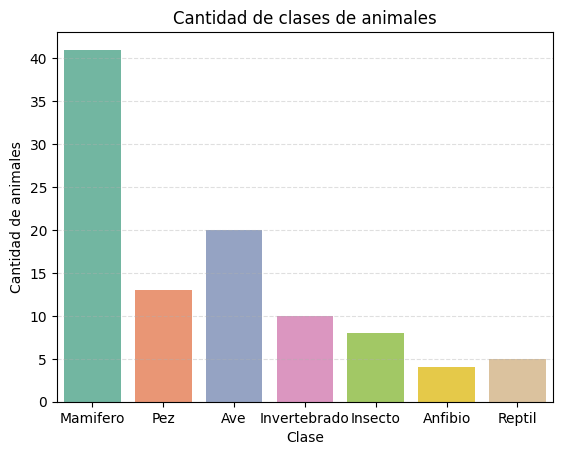

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")

sns.countplot(data=df, x="Clase", palette="Set2")

plt.title("Cantidad de clases de animales")
plt.xlabel("Clase")
plt.ylabel("Cantidad de animales")
plt.grid(axis='y',alpha=0.4, linestyle='--')

plt.show()

### Entreno con Mamifero

In [20]:
df_mam = df.copy()

df_mam["Cant_Patas"] = (df_mam["Cant_Patas"]-df_mam["Cant_Patas"].min())/(df_mam["Cant_Patas"].max()-df_mam["Cant_Patas"].min())
df_mam["Es_Mamifero"] = np.where(df_mam["Clase"] == "Mamifero", 1, 0)
df_mam = df_mam.drop(columns=["animal", "Clase"])

display(df_mam.head())

,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Es_Mamifero
0,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,0.50,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0.00,1,0,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,0.50,1,0,1,1


In [21]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_mam.drop(columns=["Es_Mamifero"]).to_numpy()
T = df_mam["Es_Mamifero"].to_numpy()

for i in range(0,5):
    ppn.fit(X,T)
    Y = ppn.predict(X)
    aciertos = np.sum(Y == T)
    
    if (aciertos == T.size):
        print("Clasifico todo correctamente", aciertos)
    else:
        print("Solo clasifico",aciertos,"de",T.size)
    
    print(ppn.w_)
    print(ppn.b_)

Clasifico todo correctamente 101
[ 0.1679 -0.6345 -0.5864  0.4123 -0.0209  0.1277 -0.2797 -0.1444  0.4214
 -0.0764  0.0457 -0.1854  0.1509 -0.0883 -0.2524  0.4459]
-0.2128770577033175
Clasifico todo correctamente 101
[-0.0905 -0.3651 -0.2978  0.7192  0.059   0.0284 -0.359   0.3796 -0.2154
  0.128   0.1525 -0.3371 -0.1217  0.0645  0.0272  0.4134]
-0.08771572563379056
Clasifico todo correctamente 101
[ 0.1729 -0.3001 -0.4032  0.5509  0.076   0.068  -0.254  -0.31    0.1598
 -0.0227  0.0867  0.2373  0.2057  0.0902  0.0702  0.2146]
-0.3475813108233548
Clasifico todo correctamente 101
[ 0.394   0.2548 -0.571   0.2653 -0.3925 -0.0263 -0.0879  0.2128  0.1045
  0.2012  0.0826 -0.4241 -0.0561 -0.4355 -0.21    0.3526]
-0.10602179589194001
Clasifico todo correctamente 101
[ 0.3128  0.143  -0.5035  0.2022 -0.3391  0.2164 -0.1204  0.161  -0.0518
  0.4716  0.2818  0.1081 -0.1605 -0.161   0.0863  0.2949]
-0.40400231384152613


Fue mas importante el atributo Toma_Leche, seguido por Tiene_Pelo

### Entreno para Aves

In [22]:
df_ave = df.copy()

df_ave["Cant_Patas"] = (df_ave["Cant_Patas"]-df_ave["Cant_Patas"].min())/(df_ave["Cant_Patas"].max()-df_ave["Cant_Patas"].min())
df_ave["Es_Ave"] = np.where(df_ave["Clase"] == "Ave", 1, 0)
df_ave = df_ave.drop(columns=["animal", "Clase"])

display(df_ave.head())

,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Es_Ave
0,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,0
1,1,0,0,1,0,0,0,1,1,1,0,0,0.50,1,0,1,0
2,0,0,1,0,0,1,1,1,1,0,0,1,0.00,1,0,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,0
4,1,0,0,1,0,0,1,1,1,1,0,0,0.50,1,0,1,0


In [23]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_ave.drop(columns=["Es_Ave"]).to_numpy()
T = df_ave["Es_Ave"].to_numpy()

for i in range(0,5):
    ppn.fit(X,T)
    Y = ppn.predict(X)
    aciertos = np.sum(Y == T)
    
    if (aciertos == T.size):
        print("Clasifico todo correctamente", aciertos)
    else:
        print("Solo clasifico",aciertos,"de",T.size)
    
    print(ppn.w_)
    print(ppn.b_)

Clasifico todo correctamente 101
[-0.091   0.5155 -0.0965 -0.118   0.2238 -0.1437  0.0085 -0.2066  0.3494
 -0.1291  0.129  -0.4814  0.2232  0.0139 -0.1698 -0.0154]
-0.2507997140329044
Clasifico todo correctamente 101
[-0.0749  0.3937  0.2055  0.0358  0.3001 -0.1166 -0.1846 -0.6293  0.5765
 -0.3345 -0.1178 -0.1522 -0.2448 -0.0889  0.1837 -0.1769]
-0.16444716656044822
Clasifico todo correctamente 101
[-0.3472  0.6947  0.0129  0.2938 -0.007   0.0629 -0.0158 -0.0925 -0.0014
  0.0325  0.2091 -0.3712 -0.0802  0.1751 -0.1089 -0.3231]
-0.43427861240874077
Clasifico todo correctamente 101
[-0.4375  0.4755 -0.3067 -0.3077  0.3167 -0.1229 -0.1266 -0.3047  0.1853
  0.4646 -0.1241  0.2439 -0.4634  0.0502  0.1357 -0.1569]
-0.16189757011180167
Clasifico todo correctamente 101
[-0.3218  0.395  -0.3425  0.0255  0.2629  0.1033 -0.2563 -0.7421 -0.1505
  0.0969  0.1508 -0.1241 -0.5624  0.2557 -0.2407  0.1316]
0.23921422191873026


Fue mas importante el atributo Tiene_Plumas

### Entreno para Reptiles

In [24]:
df_rep = df.copy()

df_rep["Cant_Patas"] = (df_rep["Cant_Patas"]-df_rep["Cant_Patas"].min())/(df_rep["Cant_Patas"].max()-df_rep["Cant_Patas"].min())
df_rep["Es_Reptil"] = np.where(df_rep["Clase"] == "Reptil", 1, 0)
df_rep = df_rep.drop(columns=["animal", "Clase"])

display(df_rep.head())

,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Es_Reptil
0,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,0
1,1,0,0,1,0,0,0,1,1,1,0,0,0.50,1,0,1,0
2,0,0,1,0,0,1,1,1,1,0,0,1,0.00,1,0,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,0.50,0,0,1,0
4,1,0,0,1,0,0,1,1,1,1,0,0,0.50,1,0,1,0


In [25]:
ppn = Perceptron(alpha=0.05, n_iter=200)

X = df_rep.drop(columns=["Es_Reptil"]).to_numpy()
T = df_rep["Es_Reptil"].to_numpy()

for i in range(0,5):
    ppn.fit(X,T)
    Y = ppn.predict(X)
    aciertos = np.sum(Y == T)
    
    if (aciertos == T.size):
        print("Clasifico todo correctamente", aciertos)
    else:
        print("Solo clasifico",aciertos,"de",T.size)
    
    print(ppn.w_)
    print(ppn.b_)

Clasifico todo correctamente 101
[ 0.1393 -0.4714 -0.0569 -0.4518 -0.1404 -0.3728  0.0261 -0.2139  0.2336
  0.0955  0.1673 -0.1149 -0.5303  0.2885 -0.4478 -0.0721]
-0.04968954054835879
Clasifico todo correctamente 101
[-0.6468 -0.2517  0.1466  0.2253 -0.2076 -0.1682 -0.124   0.1286  0.022
 -0.0755  0.1635 -0.5131 -0.1864  0.4832  0.0841 -0.0002]
-0.3203958905421907
Clasifico todo correctamente 101
[-0.0698 -0.1311 -0.0896 -0.4022 -0.2953 -0.2101 -0.0539  0.1332  0.1811
 -0.1117  0.1594 -0.4569 -0.1104  0.2439 -0.3267 -0.0047]
-0.1450431367345016
Clasifico todo correctamente 101
[-0.1063 -0.2143  0.1695 -0.3527 -0.1857 -0.5246 -0.0663  0.1409 -0.0843
 -0.1783  0.2193 -0.2306 -0.3779  0.57   -0.4993 -0.0311]
-0.24434740556726614
Clasifico todo correctamente 101
[ 0.1032 -0.1908 -0.1405 -0.5398 -0.2269 -0.3034 -0.1177  0.0892  0.298
 -0.1263  0.0122 -0.2893 -0.0306  0.1005 -0.542  -0.0004]
-0.06490900668736727


No hay atributos que destaquen

# Ejercicio 7

In [26]:
ds_path = "../Datos/automobile-simple.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head())
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,make,fuel-type,num-of-doors,body-style,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,eco-rating
0,alfa-romero,gas,two,convertible,2548,130,111.00,21,27,13495.00,528019.90,33.30
1,alfa-romero,gas,two,convertible,2548,130,111.00,21,27,16500.00,528019.90,33.30
2,alfa-romero,gas,two,hatchback,2823,152,154.00,19,26,16500.00,587592.64,30.90
3,audi,gas,four,sedan,2337,109,102.00,24,30,13950.00,634816.96,42.70
4,audi,gas,four,sedan,2824,136,115.00,18,22,17450.00,636734.83,28.00


### Primero elimino los vacios

In [27]:
df = df.dropna()
display(df.head(10))

,make,fuel-type,num-of-doors,body-style,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,eco-rating
0,alfa-romero,gas,two,convertible,2548,130,111.00,21,27,13495.00,528019.90,33.30
1,alfa-romero,gas,two,convertible,2548,130,111.00,21,27,16500.00,528019.90,33.30
2,alfa-romero,gas,two,hatchback,2823,152,154.00,19,26,16500.00,587592.64,30.90
3,audi,gas,four,sedan,2337,109,102.00,24,30,13950.00,634816.96,42.70
4,audi,gas,four,sedan,2824,136,115.00,18,22,17450.00,636734.83,28.00
5,audi,gas,two,sedan,2507,136,110.00,19,25,15250.00,624189.97,32.91
6,audi,gas,four,sedan,2844,136,110.00,19,25,17710.00,766364.05,34.34
7,audi,gas,four,wagon,2954,136,110.00,19,25,18920.00,766364.05,33.64
8,audi,gas,four,sedan,3086,131,140.00,17,20,23875.00,769115.80,27.19
10,bmw,gas,two,sedan,2395,108,101.00,23,29,16430.00,622095.55,40.23


### Calculo matriz de correlacion 

In [28]:
df_num = df.drop(columns=["make", "fuel-type", "num-of-doors", "body-style"])
corr_matrix = df_num.corr()
display(corr_matrix)

,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,eco-rating
curb-weight,1.00,0.85,0.76,-0.76,-0.80,0.83,0.82,-0.84
engine-size,0.85,1.00,0.83,-0.66,-0.68,0.87,0.59,-0.72
horsepower,0.76,0.83,1.00,-0.82,-0.80,0.81,0.45,-0.84
city-mpg,-0.76,-0.66,-0.82,1.00,0.97,-0.69,-0.55,0.98
highway-mpg,-0.80,-0.68,-0.80,0.97,1.00,-0.71,-0.61,0.98
price,0.83,0.87,0.81,-0.69,-0.71,1.00,0.63,-0.75
volume,0.82,0.59,0.45,-0.55,-0.61,0.63,1.00,-0.60
eco-rating,-0.84,-0.72,-0.84,0.98,0.98,-0.75,-0.60,1.00


### Agrego atributo es-ecologico y numerizo

In [29]:
df_new = df.copy()
df_new["es-ecologico"] = np.where(df_new["eco-rating"] > df_new["eco-rating"].mean(), 1, 0)

ohe = OneHotEncoder(sparse_output=False) 
onehot = ohe.fit_transform(df_new[["make", "body-style"]]) 
onehot_df = pd.DataFrame(onehot, columns=ohe.get_feature_names_out(["make", "body-style"]), index=df_new.index).astype(int)

df_new = pd.concat([df_new.drop(columns=["make", "body-style", "eco-rating"]), onehot_df], axis=1)

df_new["fuel-type"] = df_new["fuel-type"].map({"gas":0, "diesel":1})
df_new["num-of-doors"] = df_new["num-of-doors"].map({"two":0, "four":1})

display(df_new.head())

,fuel-type,num-of-doors,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,es-ecologico,...,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,0,0,2548,130,111.00,21,27,13495.00,528019.90,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2548,130,111.00,21,27,16500.00,528019.90,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,2823,152,154.00,19,26,16500.00,587592.64,0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,2337,109,102.00,24,30,13950.00,634816.96,1,...,0,0,0,0,0,0,0,0,1,0
4,0,1,2824,136,115.00,18,22,17450.00,636734.83,0,...,0,0,0,0,0,0,0,0,1,0


### Sin normalizar

In [30]:
df_new_non = df_new.copy()

#df_new_non = df_new_non.drop(columns=["city-mpg", "highway-mpg"])
#df_new_non = df_new_non.drop(columns=["city-mpg", "horsepower"])
df_new_non = df_new_non.drop(columns=["city-mpg","highway-mpg", "horsepower"])

ppn = Perceptron(alpha=0.05, n_iter=300)

X = df_new_non.drop(columns=["es-ecologico"]).to_numpy()
T = df_new_non["es-ecologico"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente", aciertos)
else:
    print("Solo clasifico",aciertos,"de",T.size)

print(ppn.w_)
print(ppn.b_)

Solo clasifico 104 de 197
[     32.6276     -18.3486  -86571.4935   -5417.0851 -952507.3629
   -2303.8834       0.1895       0.1214       0.104       15.9862
      -6.8475       9.7603     -15.3586       0.2813      22.9825
     -14.9452       0.1097       1.5895       0.8227      -0.0776
       2.5832       0.1986      -0.3067       0.0563       1.006
      14.7811     -15.1549     -14.6483       0.1578      55.2799
     -23.8936       0.3896]
17.290388440994914


### Normalizacion lineal

In [31]:
def normalizar(df, column):
    df[column] = (df[column] - df[column].min())/(df[column].max() - df[column].min())

df_new_lin = df_new.copy()
col = ("curb-weight", "engine-size", "horsepower", "city-mpg", "highway-mpg", "price", "volume")
for i in col:
    normalizar(df_new_lin, i)

#df_new_lin = df_new_lin.drop(columns=["city-mpg", "highway-mpg"])
#df_new_lin = df_new_lin.drop(columns=["city-mpg", "horsepower"])
df_new_lin = df_new_lin.drop(columns=["city-mpg", "highway-mpg", "horsepower"])

display(df_new_lin.head())

ppn = Perceptron(alpha=0.05, n_iter=300)

X = df_new_lin.drop(columns=["es-ecologico"]).to_numpy()
T = df_new_lin["es-ecologico"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente", aciertos)
else:
    print("Solo clasifico",aciertos,"de",T.size)

print(ppn.w_)
print(ppn.b_)

,fuel-type,num-of-doors,curb-weight,engine-size,price,volume,es-ecologico,make_alfa-romero,make_audi,make_bmw,...,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,0,0,0.41,0.26,0.21,0.19,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0.41,0.26,0.28,0.19,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0.52,0.34,0.28,0.34,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,0.33,0.18,0.22,0.46,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0.52,0.28,0.31,0.47,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


Solo clasifico 188 de 197
[ 0.4375  0.1911 -0.8821  0.9218 -2.5579  0.1006 -0.1834  0.2858 -0.0577
  0.0182  0.0051  0.2785 -0.3093  0.3521  0.2653  0.1494 -0.3772 -0.0309
  0.0934 -0.2728  0.0501  0.3235 -0.0102 -0.0621  0.1894  0.1217 -0.1024
 -0.3804 -0.0279  0.017  -0.0151  0.2321]
0.1845469885731047


### Normalizacion estandar

In [32]:
def normalizar(df, column):
    df[column] = (df[column] - df[column].mean())/df[column].std()

df_new_std = df_new.copy()
col = ("curb-weight", "engine-size", "horsepower", "city-mpg", "highway-mpg", "price", "volume")
for i in col:
    normalizar(df_new_std, i)
    
#df_new_std = df_new_std.drop(columns=["city-mpg", "highway-mpg"])
#df_new_std = df_new_std.drop(columns=["city-mpg", "horsepower"])
df_new_std = df_new_std.drop(columns=["city-mpg", "highway-mpg", "horsepower"])

display(df_new_std.head())

ppn = Perceptron(alpha=0.05, n_iter=300)

X = df_new_std.drop(columns=["es-ecologico"]).to_numpy()
T = df_new_std["es-ecologico"].to_numpy()

ppn.fit(X,T)

Y = ppn.predict(X)
aciertos = np.sum(Y == T)

if (aciertos == T.size):
    print("Clasifico todo correctamente", aciertos)
else:
    print("Solo clasifico",aciertos,"de",T.size)

print(ppn.w_)
print(ppn.b_)

,fuel-type,num-of-doors,curb-weight,engine-size,price,volume,es-ecologico,make_alfa-romero,make_audi,make_bmw,...,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon
0,0,0,-0.02,0.07,0.03,-1.15,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,-0.02,0.07,0.40,-1.15,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0.51,0.60,0.40,-0.40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,-0.42,-0.43,0.08,0.19,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0.51,0.21,0.52,0.21,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


Solo clasifico 187 de 197
[ 0.8447  0.2439 -0.1792  0.2057 -1.0702  0.1228 -0.5615  0.5259 -0.2627
 -0.0969 -0.1889  0.2323 -0.6956  0.0368  0.3559  0.0591  0.0479 -0.2144
  0.2134 -0.879  -0.1641  0.224  -0.0513 -0.2777  0.043   0.0997 -0.2127
 -0.2627 -0.5073 -0.2491 -0.33   -0.0654]
-0.2668247095280375
